<a href="https://colab.research.google.com/github/tabaraksabbah1806a-glitch/Drug-Sensitivity-Prediction-in-Cancer-Cells/blob/main/Copy_of_Alzheimer_Early_Detection_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# Libraries for data analysis
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

Early Detection of Alzheimer’s Disease Using Blood-Based Gene Expression Data

Dataset: GEO (GSE63060)
Student: Tabarak Sabah Shaalan

In [4]:
!pip install GEOparse

In [5]:
import GEOparse

gse = GEOparse.get_GEO("GSE63060", destdir="./")

10-Apr-2026 13:30:18 DEBUG utils - Directory ./ already exists. Skipping.
DEBUG:GEOparse:Directory ./ already exists. Skipping.
10-Apr-2026 13:30:18 INFO GEOparse - Downloading ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE63nnn/GSE63060/soft/GSE63060_family.soft.gz to ./GSE63060_family.soft.gz
INFO:GEOparse:Downloading ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE63nnn/GSE63060/soft/GSE63060_family.soft.gz to ./GSE63060_family.soft.gz
100%|██████████| 120M/120M [00:00<00:00, 340MB/s] 
10-Apr-2026 13:30:19 DEBUG downloader - Size validation passed
DEBUG:GEOparse:Size validation passed
10-Apr-2026 13:30:19 DEBUG downloader - Moving /tmp/tmpdhvyuoez to /content/GSE63060_family.soft.gz
DEBUG:GEOparse:Moving /tmp/tmpdhvyuoez to /content/GSE63060_family.soft.gz
10-Apr-2026 13:30:19 DEBUG downloader - Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE63nnn/GSE63060/soft/GSE63060_family.soft.gz
DEBUG:GEOparse:Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE63nnn/GSE6306

In [6]:
print(gse)

<SERIES: GSE63060 - 329 SAMPLES, 1 d(s)>


In [7]:
# Extract expression data
samples = gse.gsms

data_list = []

for sample in samples.values():
    df = sample.table
    df = df[['ID_REF', 'VALUE']]
    df.columns = ['Gene', sample.name]
    data_list.append(df.set_index('Gene'))

expression_data = pd.concat(data_list, axis=1)

expression_data.head()

,GSM1539080,GSM1539081,GSM1539082,GSM1539083,GSM1539084,GSM1539085,GSM1539086,GSM1539087,GSM1539088,GSM1539089,...,GSM1539399,GSM1539400,GSM1539401,GSM1539402,GSM1539403,GSM1539404,GSM1539405,GSM1539406,GSM1539407,GSM1539408
Gene,,,,,,,,,,,,,,,,,,,,,
ILMN_2055271,7.600951,7.672496,7.538046,7.577860,7.678150,7.821754,7.538325,7.595028,7.617149,7.893230,...,7.577844,7.657990,7.702664,7.549431,7.424009,7.563977,7.606099,7.545535,7.567928,7.567190
ILMN_2383229,7.401991,7.414577,7.406980,7.455003,7.354241,7.487114,7.473277,7.414765,7.369689,7.425769,...,7.420044,7.327676,7.395640,7.455264,7.437403,7.296285,7.476446,7.365189,7.385004,7.411265
ILMN_1806310,7.650042,7.469146,7.478494,7.486963,7.446429,7.576292,7.408330,7.554633,7.430346,7.568055,...,7.648986,7.528787,7.527087,7.393601,7.511023,7.447771,7.507259,7.411622,7.456276,7.646164
ILMN_1779670,7.439318,7.505310,7.542144,7.567281,7.450938,7.664372,7.461290,7.591936,7.413166,7.438316,...,7.505358,7.490749,7.426290,7.428289,7.449399,7.499828,7.557032,7.497207,7.582703,7.498368
ILMN_2321282,7.538710,7.687544,7.602953,7.657317,7.615673,7.603043,7.537349,7.661408,7.624915,7.431161,...,7.693395,7.560890,7.411534,7.397306,7.544783,7.556252,7.575734,7.539473,7.578211,7.541192


In [8]:
expression_data.shape

(38323, 329)

In [9]:
expression_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 38323 entries, ILMN_2055271 to ILMN_2137536
Columns: 329 entries, GSM1539080 to GSM1539408
dtypes: float64(329)
memory usage: 96.5+ MB


In [10]:
# Extract sample information
metadata = []

for gsm_name, gsm in gse.gsms.items():
    metadata.append({
        "sample": gsm_name,
        "title": gsm.metadata.get("title", [""])[0],
        "source": gsm.metadata.get("source_name_ch1", [""])[0]
    })

metadata_df = pd.DataFrame(metadata)

metadata_df.head()

,sample,title,source
0,GSM1539080,4856050008_I,Blood
1,GSM1539081,4856050047_D,Blood
2,GSM1539082,4856076009_D,Blood
3,GSM1539083,4856076040_F,Blood
4,GSM1539084,4856076002_E,Blood


In [11]:
metadata_df.shape

(329, 3)

In [12]:
metadata_df['source'].value_counts()

,count
source,
Blood,329


In [13]:
metadata_df.head(10)

,sample,title,source
0,GSM1539080,4856050008_I,Blood
1,GSM1539081,4856050047_D,Blood
2,GSM1539082,4856076009_D,Blood
3,GSM1539083,4856076040_F,Blood
4,GSM1539084,4856076002_E,Blood
5,GSM1539085,4856076041_H,Blood
6,GSM1539086,4856076040_G,Blood
7,GSM1539087,4856076023_G,Blood
8,GSM1539088,4856076040_C,Blood
9,GSM1539089,4856050047_B,Blood


In [14]:
# Check characteristics field
for gsm_name, gsm in list(gse.gsms.items())[:5]:
    print(gsm.metadata.get("characteristics_ch1"))
    print("-----")

['status: MCI', 'ethnicity: Western European', 'age: 65', 'gender: Female', 'included in case -control study: yes', 'tissue: blood']
-----
['status: MCI', 'ethnicity: Other Caucasian', 'age: 66', 'gender: Female', 'included in case -control study: yes', 'tissue: blood']
-----
['status: MCI', 'ethnicity: Western European', 'age: 67', 'gender: Female', 'included in case -control study: yes', 'tissue: blood']
-----
['status: MCI', 'ethnicity: Unknown', 'age: 67', 'gender: Female', 'included in case -control study: yes', 'tissue: blood']
-----
['status: MCI', 'ethnicity: Western European', 'age: 67', 'gender: Female', 'included in case -control study: yes', 'tissue: blood']
-----


In [15]:
metadata = []

for gsm_name, gsm in gse.gsms.items():
    characteristics = gsm.metadata.get("characteristics_ch1", [])

    status = None
    for item in characteristics:
        if "status" in item:
            status = item.split(": ")[1]

    metadata.append({
        "sample": gsm_name,
        "status": status
    })

metadata_df = pd.DataFrame(metadata)

metadata_df.head()

,sample,status
0,GSM1539080,MCI
1,GSM1539081,MCI
2,GSM1539082,MCI
3,GSM1539083,MCI
4,GSM1539084,MCI


In [16]:
metadata_df['status'].value_counts()

,count
status,
AD,145
CTL,104
MCI,80


Alzheimer vs Healthy

In [17]:
# Keep only AD and Control
filtered_metadata = metadata_df[
    metadata_df['status'].isin(['AD', 'CTL'])
]

filtered_metadata.shape

(249, 2)

In [18]:
# Match samples between expression data and metadata
selected_samples = filtered_metadata['sample'].values

filtered_expression = expression_data[selected_samples]

filtered_expression.shape

(38323, 249)

In [19]:
labels = filtered_metadata.set_index('sample').loc[selected_samples]['status']
labels = labels.map({'AD':1, 'CTL':0})

labels.head()

,status
sample,
GSM1539119,0
GSM1539120,0
GSM1539121,0
GSM1539122,0
GSM1539123,0


In [20]:
labels.value_counts()

,count
status,
1,145
0,104


In [21]:
!pip install GEOparse

In [22]:
import GEOparse
import pandas as pd

gse = GEOparse.get_GEO("GSE63060", destdir="./")

10-Apr-2026 13:31:05 DEBUG utils - Directory ./ already exists. Skipping.
DEBUG:GEOparse:Directory ./ already exists. Skipping.
10-Apr-2026 13:31:05 INFO GEOparse - File already exist: using local version.
INFO:GEOparse:File already exist: using local version.
10-Apr-2026 13:31:05 INFO GEOparse - Parsing ./GSE63060_family.soft.gz: 
INFO:GEOparse:Parsing ./GSE63060_family.soft.gz: 
10-Apr-2026 13:31:05 DEBUG GEOparse - DATABASE: GeoMiame
DEBUG:GEOparse:DATABASE: GeoMiame
10-Apr-2026 13:31:05 DEBUG GEOparse - SERIES: GSE63060
DEBUG:GEOparse:SERIES: GSE63060
10-Apr-2026 13:31:05 DEBUG GEOparse - PLATFORM: GPL6947
DEBUG:GEOparse:PLATFORM: GPL6947
10-Apr-2026 13:31:06 DEBUG GEOparse - SAMPLE: GSM1539080
DEBUG:GEOparse:SAMPLE: GSM1539080
10-Apr-2026 13:31:06 DEBUG GEOparse - SAMPLE: GSM1539081
DEBUG:GEOparse:SAMPLE: GSM1539081
10-Apr-2026 13:31:06 DEBUG GEOparse - SAMPLE: GSM1539082
DEBUG:GEOparse:SAMPLE: GSM1539082
10-Apr-2026 13:31:06 DEBUG GEOparse - SAMPLE: GSM1539083
DEBUG:GEOparse:SAMP

In [23]:
# Extract expression data
samples = gse.gsms
data_list = []

for sample in samples.values():
    df = sample.table
    df = df[['ID_REF', 'VALUE']]
    df.columns = ['Gene', sample.name]
    data_list.append(df.set_index('Gene'))

expression_data = pd.concat(data_list, axis=1)

# Extract metadata
metadata = []

for gsm_name, gsm in gse.gsms.items():
    characteristics = gsm.metadata.get("characteristics_ch1", [])

    status = None
    for item in characteristics:
        if "status" in item:
            status = item.split(": ")[1]

    metadata.append({
        "sample": gsm_name,
        "status": status
    })

metadata_df = pd.DataFrame(metadata)

# Filter AD and Control
filtered_metadata = metadata_df[
    metadata_df['status'].isin(['AD', 'CTL'])
]

selected_samples = filtered_metadata['sample'].values

filtered_expression = expression_data[selected_samples]

labels = filtered_metadata.set_index('sample').loc[selected_samples]['status']
labels = labels.map({'AD':1, 'CTL':0})

print("Dataset ready for modelling")

Dataset ready for modelling


(Feature Selection)

In [24]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif

# Transpose data (samples rows, genes columns)
X = filtered_expression.T

y = labels

In [25]:
selector = SelectKBest(score_func=f_classif, k=100)

X_selected = selector.fit_transform(X, y)

X_selected.shape

(249, 100)

In [26]:
selected_genes = X.columns[selector.get_support()]

selected_genes[:10]

Index(['ILMN_1703538', 'ILMN_1792473', 'ILMN_1673815', 'ILMN_1655561',
       'ILMN_1756674', 'ILMN_2225887', 'ILMN_1726603', 'ILMN_1652806',
       'ILMN_1772929', 'ILMN_2348093'],
      dtype='object', name='Gene')

In [27]:
len(selected_genes)

100

In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

model = RandomForestClassifier()

scores = cross_val_score(model, X_selected, y, cv=5)

print("Accuracy:", scores.mean())

Accuracy: 0.7591020408163265


In [29]:
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score

model = SVC(kernel='linear')

scores = cross_val_score(model, X_selected, y, cv=5)

print("SVM Accuracy:", scores.mean())

SVM Accuracy: 0.7831020408163265


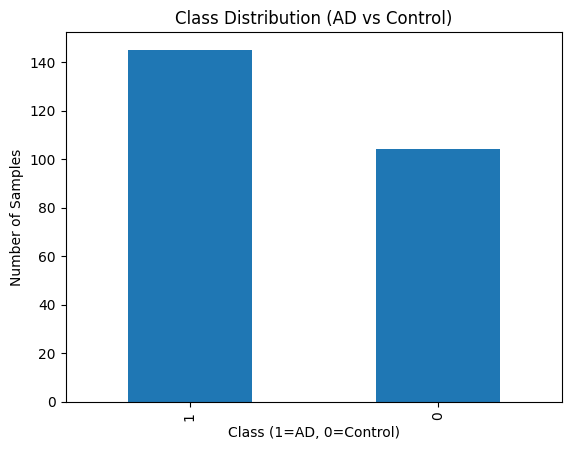

In [30]:
import matplotlib.pyplot as plt

labels.value_counts().plot(kind='bar')
plt.title("Class Distribution (AD vs Control)")
plt.xlabel("Class (1=AD, 0=Control)")
plt.ylabel("Number of Samples")
plt.show()

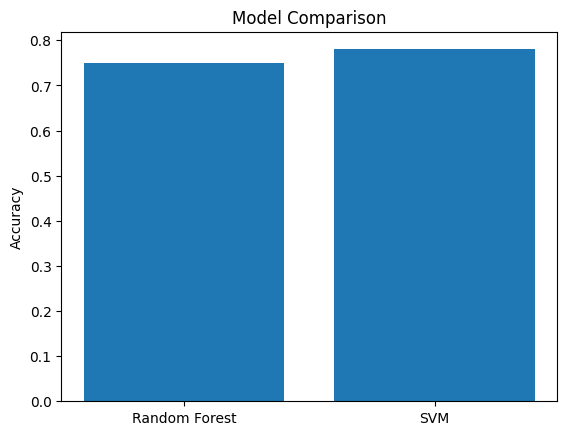

In [31]:
models = ['Random Forest', 'SVM']
accuracies = [0.75, 0.78]

plt.bar(models, accuracies)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()

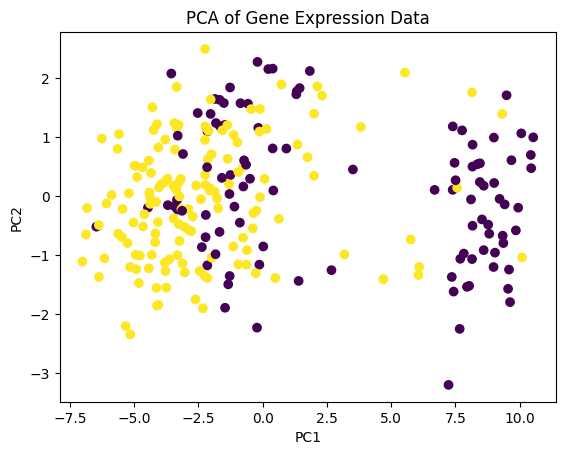

In [32]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_selected)

plt.scatter(X_pca[:,0], X_pca[:,1], c=y)
plt.title("PCA of Gene Expression Data")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

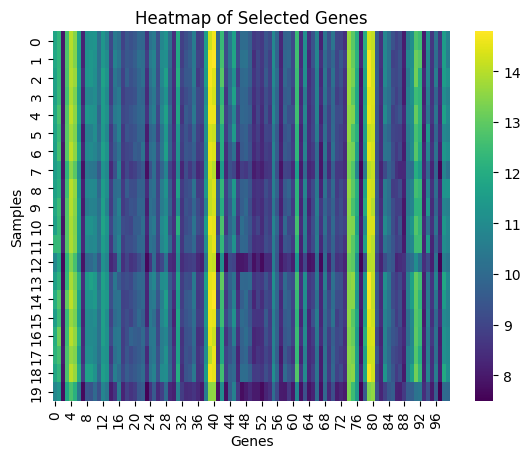

In [33]:
import seaborn as sns

# نأخذ أول 20 عينة لتوضيح الرسم
sns.heatmap(X_selected[:20], cmap='viridis')

plt.title("Heatmap of Selected Genes")
plt.xlabel("Genes")
plt.ylabel("Samples")
plt.show()